# ICML Paper Figures

Paper-quality figures for ICML submission. All figures are formatted for two-column (figure*) layout.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import LogLocator
import re
import os
from pathlib import Path
import wandb_buddy as wb

## ICML Paper Style Configuration

ICML two-column format:
- Text width: ~6.75 inches (full page figure*)
- Column width: ~3.25 inches (single column / subfigure)
- Font: Serif (Times) to match ICML LaTeX template

In [8]:
# ICML Paper Style - exact widths for single/double column
ICML_WIDTH_SINGLE = 3.25  # inches for single column
ICML_WIDTH_DOUBLE = 6.75  # inches for double column (figure*)

def setup_icml_style():
    """Configure matplotlib for ICML paper figures."""
    plt.rcParams.update({
        "text.usetex": True,           # Use LaTeX to render text
        "font.family": "serif",        # Use serif fonts to match paper
        "font.serif": ["Times"],       # Match the ICML Times New Roman
        "font.size": 6,               # Match body text size
        "axes.labelsize": 6,          # x/y label size
        "axes.titlesize": 6,          # Subplot title size
        "legend.fontsize": 7,          # Legend can be smaller
        "xtick.labelsize": 7,          # Ticks can be smaller
        "ytick.labelsize": 7,
        "figure.figsize": (ICML_WIDTH_SINGLE, 2.0),  # Width fixed, height adjustable
        "figure.autolayout": True,     # Similar to tight_layout
    })

setup_icml_style()
print("ICML paper style configured.")

ICML paper style configured.


## NeurIPS 2026 Paper Style (locked palette)

Drop-in style from `notebooks/PLOTTING_STYLE.md` — locked colours/markers/line treatment so all figures in the paper read consistently. This supersedes the ICML style above for any figure intended for the NeurIPS submission.

In [9]:
import matplotlib as mpl

# Locked palette — do not change without updating PLOTTING_STYLE.md
PALETTE = {
    "GNN":       "#7f8c8d",
    "Exphormer": "#e07a5f",
    "GraphGPS":  "#f2cc8f",
    "Dense GT":  "#3d5a80",
    "Sparse GT": "#81b29a",
}
MARKERS = {
    "GNN":       "o",
    "Exphormer": "s",
    "GraphGPS":  "^",
    "Dense GT":  "D",
    "Sparse GT": "v",
}
BASELINES = {"GNN"}
PROPOSED  = {"Dense GT", "Sparse GT"}

# Map experiment-specific model labels onto locked palette keys.
# All SparseGT variants share the locked Sparse GT colour (#81b29a) per
# PLOTTING_STYLE.md so the model reads identically across repos. Variants
# (Random / Data / Best) appear one-per-figure so the legend label alone
# disambiguates them.
MODEL_STYLE_KEY = {
    "GNN":             "GNN",
    "Sparse GT":       "Sparse GT",
    "Dense GT":        "Dense GT",
    "SparseGT-Random": "Sparse GT",
    "SparseGT-Data":   "Sparse GT",
    "SparseGT-Best":   "Sparse GT",
}

# Sized for in-paper rendering at NeurIPS textwidth (~5.5 in), not screen previews.
def line_attrs(style_key, base_lw=1.2, base_ms=3.5):
    if style_key in BASELINES:
        return dict(lw=base_lw * 0.55, ms=base_ms * 0.78,
                    alpha=0.78, ls="--", zorder=2)
    if style_key in PROPOSED:
        return dict(lw=base_lw * 1.05, ms=base_ms * 1.05,
                    alpha=1.0, ls="-", zorder=5)
    return dict(lw=base_lw, ms=base_ms, alpha=0.95, ls="-", zorder=3)

# NeurIPS 2026 body text is 10-pt Times Roman. Plot text matches the body.
NEURIPS_RC = {
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    "axes.unicode_minus": False,
    "text.usetex":       False,
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":  "stix",
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "axes.titlepad":     4,
    "axes.titlelocation": "left",
    "legend.fontsize":   8,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "axes.linewidth":    0.7,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
}

def apply_neurips_style():
    mpl.rcParams.update(NEURIPS_RC)

def style_axes(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("#444")
    ax.spines["bottom"].set_color("#444")
    ax.tick_params(colors="#444")

def plot_model(ax, x, y, label, style_key=None):
    """Plot a single model line with locked style."""
    sk = style_key or MODEL_STYLE_KEY.get(label, label)
    ax.plot(x, y,
            marker=MARKERS[sk], color=PALETTE[sk], label=label,
            markeredgecolor="white", markeredgewidth=0.5,
            **line_attrs(sk))

apply_neurips_style()
print("NeurIPS paper style configured.")


NeurIPS paper style configured.


## Load Data

In [13]:
# =============================================================================
# 1. Load wandb experiment data for transferability plot
# =============================================================================
TAG = "e23TG_neurogf_terrain_graph_2"
ENTITY = "alelab"
PROJECT = "terrains"
ERROR_COL = 'test_mae'
ERROR_LABEL = 'Test MAE'

print(f"Fetching runs with tag: {TAG}")
df = wb.load_runs(ENTITY, PROJECT, tags=[TAG])
print(f"Found {len(df)} runs")

Fetching runs with tag: e23TG_neurogf_terrain_graph_2


KeyboardInterrupt: 

In [ ]:
# Extract resolution from dataset_name
def extract_resolution(row):
    dataset_name = str(row['dataset_name'])
    res_match = re.search(r'res(\d+)', dataset_name)
    return int(res_match.group(1))

df['resolution'] = df.apply(extract_resolution, axis=1)
df['density'] = 1 / (df['resolution'] ** 2)
print(f"Resolutions: {sorted(df['resolution'].unique())}")

Resolutions: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)]


In [ ]:
# Compute test_mae and test_nmae from batch history
import wandb
from tqdm import tqdm

def get_metric_history_mean(entity: str, project: str, run_id: str, metric: str) -> float:
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan

def add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df['id'], desc=f"Fetching {source_metric}"):
        means.append(get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

df = add_metric_from_history(df, ENTITY, PROJECT, 'test_batch_mae', 'test_mae')
df = add_metric_from_history(df, ENTITY, PROJECT, 'test_batch_nmae', 'test_nmae')

# Switch to NMAE for all plots
ERROR_COL = 'test_nmae'
ERROR_LABEL = 'Test NMAE'

print(f"Runs with valid test_nmae: {df['test_nmae'].notna().sum()} / {len(df)}")

Fetching test_batch_mae:  10%|▉         | 10/102 [00:09<01:26,  1.06it/s]


KeyboardInterrupt: 

In [ ]:
# Compute best performance per resolution
df_valid = df.dropna(subset=[ERROR_COL])

# Compute num_nodes from resolution (Norway 2000x2000 terrain)
ORIGINAL_DIM = 2000
df_valid['num_nodes'] = df_valid['resolution'].apply(
    lambda r: ((ORIGINAL_DIM - 1) // r + 1) ** 2
)

best_per_resolution = df_valid.loc[df_valid.groupby(['layer_type', 'resolution'])[ERROR_COL].idxmin()]
print(f"Best runs per resolution: {len(best_per_resolution)}")

Best runs per resolution: 73


/tmp/ipykernel_1727011/2695818547.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['num_nodes'] = df_valid['resolution'].apply(


In [ ]:
# =============================================================================
# 2. Load terrain data for heatmap
# =============================================================================
data_dir = Path('..') / 'data'

def load_terrain_from_txt(txt_path):
    """
    Load terrain data from a txt file.
    Format: first line is 'rows cols', rest is elevation data.
    """
    with open(txt_path, 'r') as f:
        first_line = f.readline().strip()
        rows, cols = map(int, first_line.split())
        
        terrain = []
        for line in f:
            row_values = list(map(float, line.strip().split()))
            terrain.append(row_values)
    
    terrain = np.array(terrain)
    return terrain, rows, cols

# Load Norway terrain
txt_path = data_dir / 'norway-smallest.txt'
print(f"Loading terrain from: {txt_path}")
terrain_full, rows, cols = load_terrain_from_txt(txt_path)
print(f"Terrain dimensions: {rows} x {cols} = {rows * cols:,} nodes")
print(f"Height range: [{terrain_full.min():.2f}, {terrain_full.max():.2f}]")

Loading terrain from: ../data/norway-smallest.txt
Terrain dimensions: 2000 x 2000 = 4,000,000 nodes
Height range: [899.70, 2316.50]


## Figure 1: Terrain + Transferability (Separate Subfigures)

Two separate figures to combine in LaTeX using `\subfigure`:
- (a) `icml_terrain_heatmap.pdf` - Norway terrain heatmap
- (b) `icml_transferability.pdf` - Model performance vs graph size

Example LaTeX usage:
```latex
\begin{figure*}[t]
    \centering
    \begin{subfigure}[b]{0.45\textwidth}
        \centering
        \includegraphics[width=\textwidth]{figures/icml_terrain_heatmap.pdf}
        \caption{Norway terrain (2000$\times$2000 elevation grid)}
        \label{fig:terrain}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.45\textwidth}
        \centering
        \includegraphics[width=\textwidth]{figures/icml_transferability.pdf}
        \caption{Transferability across graph resolutions}
        \label{fig:transferability}
    \end{subfigure}
    \caption{...}
\end{figure*}
```

In [2]:
# Ensure ICML style is set and create figures directory
setup_icml_style()
os.makedirs('figures', exist_ok=True)

# =============================================================================
# Figure (a): Terrain Heatmap - Separate figure for LaTeX subfigure
# =============================================================================
fig_terrain, ax_terrain = plt.subplots(figsize=(ICML_COLUMN_WIDTH, ICML_COLUMN_WIDTH))

# Plot terrain heatmap
im = ax_terrain.imshow(terrain_full, cmap='terrain', aspect='equal')

# Remove axis ticks
ax_terrain.set_xticks([])
ax_terrain.set_yticks([])

# Add colorbar
cbar = plt.colorbar(im, ax=ax_terrain, shrink=0.9, pad=0.02)
cbar.set_label('Height (m)')

# Save terrain figure
fig_terrain.savefig('figures/icml_terrain_heatmap.pdf', dpi=300, bbox_inches='tight')
fig_terrain.savefig('figures/icml_terrain_heatmap.png', dpi=300, bbox_inches='tight')

print("Saved: figures/icml_terrain_heatmap.pdf")
print("Saved: figures/icml_terrain_heatmap.png")
plt.show()

NameError: name 'setup_icml_style' is not defined

In [3]:
best_per_resolution.resolution

NameError: name 'best_per_resolution' is not defined

In [4]:
# =============================================================================
# Figure (b): Norway transferability — locked NeurIPS style
# =============================================================================
apply_neurips_style()

LABEL_MAP = {"TAGConv": "GNN", "SparseGT": "Sparse GT"}

df_plot = best_per_resolution.copy().query("resolution>=5")
df_plot["Model"] = df_plot["layer_type"].map(LABEL_MAP)

with mpl.rc_context(NEURIPS_RC):
    fig_transfer, ax_transfer = plt.subplots(figsize=(2.75, 2.0),
                                             constrained_layout=True)

    for model_name in ["GNN", "Sparse GT"]:
        sub = df_plot[df_plot["Model"] == model_name].sort_values("num_nodes")
        if sub.empty:
            continue
        plot_model(ax_transfer, sub["num_nodes"], sub[ERROR_COL], model_name)

    ax_transfer.set_xscale("log")
    ax_transfer.set_xlabel(r"Training Size ($N$)")
    ax_transfer.set_ylabel(ERROR_LABEL)
    style_axes(ax_transfer)
    ax_transfer.legend(loc="upper right", frameon=False)

    fig_transfer.savefig("figures/neurips_norway_transferability.pdf",
                         bbox_inches="tight", pad_inches=0.02)
    fig_transfer.savefig("figures/neurips_norway_transferability.png",
                         dpi=300, bbox_inches="tight", pad_inches=0.02)

print("Saved: figures/neurips_norway_transferability.pdf")
print("Saved: figures/neurips_norway_transferability.png")
plt.show()


NameError: name 'apply_neurips_style' is not defined

## Hybrid Sampling: Norway, Philly, Cross-terrain (best setting per model)

Plots transferability across graph resolutions for the hybrid sampling experiments.
- Norway hybrid: tag `e29TR_norway_hybrid_sampling_full_test` (2000x2000 terrain)
- Philly  hybrid: tag `e28TR_philly_hybrid_sampling_full_test` (1000x1000 terrain)
- Cross-terrain (train Philly, test Norway): tag `e30TR_cross_terrain_train_philly_test_norway` (test on Norway, dim 2000)

For each (terrain, model_label, resolution) we keep the best run by `test_mae`.

In [10]:
# =============================================================================
# Load hybrid sampling runs (Norway, Philadelphia)
# =============================================================================
import wandb
from tqdm import tqdm

ENTITY = "alelab"
PROJECT = "terrains"

HYBRID_TAGS = {
    "Norway":       {"tag": "e29TR_norway_hybrid_sampling_full_test", "original_dim": 2000},
    "Philadelphia": {"tag": "e28TR_philly_hybrid_sampling_full_test", "original_dim": 1000},
}

def _extract_resolution(row):
    res_match = re.search(r"res(\d+)", str(row.get("dataset_name", "")))
    if res_match:
        return int(res_match.group(1))
    res_match = re.search(r"res(\d+)", str(row.get("name", "")))
    return int(res_match.group(1)) if res_match else np.nan

def _get_metric_history_mean(entity, project, run_id, metric):
    api = wandb.Api()
    run = api.run(f"{entity}/{project}/{run_id}")
    history = run.history(keys=[metric], pandas=True)
    if history.empty or metric not in history.columns:
        return np.nan
    values = history[metric].dropna()
    return values.mean() if len(values) > 0 else np.nan

def _add_metric_from_history(df, entity, project, source_metric, target_col):
    means = []
    for run_id in tqdm(df["id"], desc=f"Fetching {source_metric}"):
        means.append(_get_metric_history_mean(entity, project, run_id, source_metric))
    df[target_col] = means
    return df

def load_hybrid_runs(tag, original_dim):
    print(f"Fetching runs with tag: {tag}")
    df = wb.load_runs(ENTITY, PROJECT, tags=[tag])
    print(f"  Found {len(df)} runs")
    if len(df) == 0:
        return df

    df["resolution"] = df.apply(_extract_resolution, axis=1)
    df = df.dropna(subset=["resolution"]).copy()
    df["resolution"] = df["resolution"].astype(int)
    df["num_nodes"] = df["resolution"].apply(
        lambda r: ((original_dim - 1) // r + 1) ** 2
    )

    if "layer_type" not in df.columns or df["layer_type"].isna().any():
        df["layer_type"] = df["name"].str.extract(r"(TAGConv|SparseGT)", expand=False)

    api = wandb.Api()
    embed_modes = {}
    sgt = df[df["layer_type"] == "SparseGT"]
    for _, row in tqdm(sgt.iterrows(), total=len(sgt), desc="  embedding_mode"):
        try:
            run = api.run(f"{ENTITY}/{PROJECT}/{row['id']}")
            embed_modes[row["id"]] = run.config.get("sparse_gt_embedding_mode", None)
        except Exception:
            embed_modes[row["id"]] = None
    df["sparse_gt_embedding_mode"] = df["id"].map(embed_modes)

    def _label(row):
        if row["layer_type"] == "TAGConv":
            return "GNN"
        if row["sparse_gt_embedding_mode"] == "random":
            return "SparseGT-Random"
        if row["sparse_gt_embedding_mode"] == "data":
            return "SparseGT-Data"
        return "SparseGT"
    df["model_label"] = df.apply(_label, axis=1)

    df = _add_metric_from_history(df, ENTITY, PROJECT, "test_batch_mae", "test_mae")
    df = _add_metric_from_history(df, ENTITY, PROJECT, "test_batch_nmae", "test_nmae")
    return df

hybrid_data = {}
for terrain, cfg in HYBRID_TAGS.items():
    hybrid_data[terrain] = load_hybrid_runs(cfg["tag"], cfg["original_dim"])
    n_valid = hybrid_data[terrain]["test_nmae"].notna().sum() if len(hybrid_data[terrain]) else 0
    print(f"{terrain}: {n_valid} runs with valid test_nmae\n")


wandb: Currently logged in as: jotaporras (alelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetching runs with tag: e29TR_norway_hybrid_sampling_full_test
  Found 63 runs


Fetching test_batch_nmae: 100%|██████████| 63/63 [00:51<00:00,  1.23it/s]


Norway: 63 runs with valid test_nmae

Fetching runs with tag: e28TR_philly_hybrid_sampling_full_test
  Found 60 runs


Fetching test_batch_nmae: 100%|██████████| 60/60 [00:50<00:00,  1.18it/s]

Philadelphia: 60 runs with valid test_nmae



In [11]:
# Best run per (model_label, resolution) for each terrain — selecting on NMAE
HYBRID_ERROR_COL = "test_nmae"
HYBRID_ERROR_LABEL = "Test NMAE"

hybrid_best = {}
for terrain, df_t in hybrid_data.items():
    if len(df_t) == 0:
        hybrid_best[terrain] = df_t
        continue
    df_valid = df_t.dropna(subset=[HYBRID_ERROR_COL]).query("resolution >= 2")
    best = df_valid.loc[
        df_valid.groupby(["model_label", "resolution"])[HYBRID_ERROR_COL].idxmin()
    ]
    hybrid_best[terrain] = best
    print(f"{terrain}: {len(best)} best runs across {best['resolution'].nunique()} resolutions")
    print(best.groupby('model_label').size().to_dict())
    print()

Norway: 54 best runs across 19 resolutions
{'GNN': 19, 'SparseGT-Data': 17, 'SparseGT-Random': 18}

Philadelphia: 55 best runs across 19 resolutions
{'GNN': 19, 'SparseGT-Data': 18, 'SparseGT-Random': 18}



### Plot

Saved: figures/neurips_hybrid_sampling_ver_a.pdf
Saved: figures/neurips_hybrid_sampling_ver_a.png


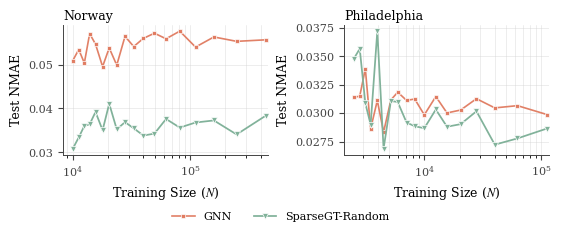

Saved: figures/neurips_hybrid_sampling_ver_b.pdf
Saved: figures/neurips_hybrid_sampling_ver_b.png


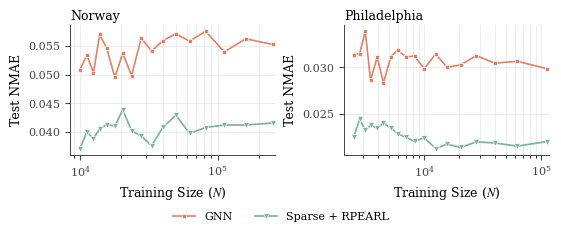

Saved: figures/neurips_hybrid_sampling_ver_c.pdf
Saved: figures/neurips_hybrid_sampling_ver_c.png


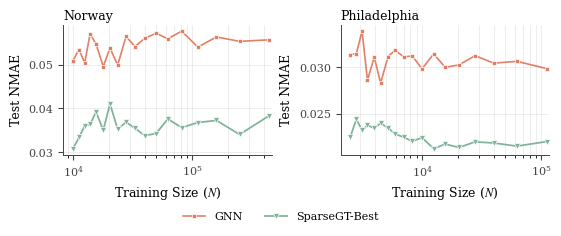

In [14]:
# =============================================================================
# Hybrid sampling figures (NMAE) — Norway | Philly side-by-side
# Locked NeurIPS style. Three versions:
#   ver_a: GNN + SparseGT-Random
#   ver_b: GNN + SparseGT-Data
#   ver_c: GNN + best SparseGT per resolution
# In this section GNN is given the Exphormer slot (orange, solid) so it
# isn't muted as the dashed baseline.
# =============================================================================
apply_neurips_style()

# Override GNN -> Exphormer style only for this section
GNN_STYLE_KEY = "Exphormer"

VERSIONS = {
    "ver_a": ("GNN vs SparseGT-Random", ["GNN", "SparseGT-Random"]),
    "ver_b": ("GNN vs SparseGT-Data",   ["GNN", "SparseGT-Data"]),
    "ver_c": ("GNN vs best SparseGT",   ["GNN", "SparseGT-Best"]),
}
PANEL_ORDER = ["Norway", "Philadelphia"]

def _series_for_model(best_df, model_name):
    if model_name == "SparseGT-Best":
        sgt = best_df[best_df["model_label"].isin(["SparseGT-Random", "SparseGT-Data"])]
        if sgt.empty:
            return sgt
        idx = sgt.groupby("resolution")[HYBRID_ERROR_COL].idxmin()
        return sgt.loc[idx]
    return best_df[best_df["model_label"] == model_name]

for ver_key, (ver_title, models) in VERSIONS.items():
    with mpl.rc_context(NEURIPS_RC):
        fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.0),
                                 constrained_layout=True, sharey=False)
        for ax, terrain in zip(axes, PANEL_ORDER):
            best = hybrid_best.get(terrain)
            if best is None or len(best) == 0:
                ax.set_title(f"{terrain} (no data)")
                style_axes(ax)
                continue

            # Determine x-axis cutoff: largest num_nodes that the SparseGT
            # variant has data for (so GNN isn't extrapolated past it).
            sgt_models = [m for m in models if m != "GNN"]
            sgt_data = pd.concat(
                [_series_for_model(best, m) for m in sgt_models],
                ignore_index=True,
            ) if sgt_models else None
            x_max = sgt_data["num_nodes"].max() if sgt_data is not None and not sgt_data.empty else None

            for model_name in models:
                sub = _series_for_model(best, model_name).sort_values("num_nodes")
                if sub.empty:
                    continue
                if x_max is not None:
                    sub = sub[sub["num_nodes"] <= x_max]
                style_key = GNN_STYLE_KEY if model_name == "GNN" else MODEL_STYLE_KEY.get(model_name, model_name)
                display_label = "Sparse + RPEARL" if (ver_key == "ver_b" and model_name == "SparseGT-Data") else model_name
                plot_model(ax, sub["num_nodes"], sub[HYBRID_ERROR_COL],
                           display_label, style_key=style_key)

            ax.set_xscale("log")
            ax.set_xlabel(r"Training Size ($N$)")
            ax.set_ylabel(HYBRID_ERROR_LABEL)
            ax.set_title(terrain)
            ax.grid(True, which="both", color="lightgray",
                    linestyle="-", linewidth=0.4, alpha=0.7, zorder=0)
            style_axes(ax)
            if x_max is not None:
                ax.set_xlim(right=x_max * 1.05)

        # Shared legend below axes — pushed further down to avoid x-axis overlap
        handles, labels = [], []
        for ax in axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels:
                    handles.append(h); labels.append(l)
        if handles:
            fig.legend(handles, labels,
                       loc="lower center", ncol=len(labels),
                       frameon=False, bbox_to_anchor=(0.5, -0.13))

        pdf_path = f"figures/neurips_hybrid_sampling_{ver_key}.pdf"
        png_path = f"figures/neurips_hybrid_sampling_{ver_key}.png"
        fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.05)
        fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
        print(f"Saved: {pdf_path}")
        print(f"Saved: {png_path}")
        plt.show()


### Table: Hybrid Sampling Transferability — best NMAE per resolution

Numerical companion to the `neurips_hybrid_sampling_ver_{a,b,c}` plots above.
Rows: (resolution, graph size *n*). Columns: GNN, SparseGT-Random ("Rnd"), SparseGT-Data ("Data").
LaTeX source is printed below each table for direct inclusion in the paper.

In [5]:
# =============================================================================
# Table: Hybrid Sampling Transferability — best Test NMAE per resolution
# Accompanies figures/neurips_hybrid_sampling_ver_{a,b,c}.{pdf,png}
# =============================================================================
from IPython.display import display

ALL_MODELS_TABLE = ["GNN", "SparseGT-Random", "SparseGT-Data"]
RENAME_MODEL = {
    "GNN":             "GNN",
    "SparseGT-Random": "SparseGT (Rnd)",
    "SparseGT-Data":   "SparseGT (Data)",
}

rows_t = []
for terrain in PANEL_ORDER:
    best_df = hybrid_best.get(terrain)
    if best_df is None or len(best_df) == 0:
        continue
    for model_name in ALL_MODELS_TABLE:
        sub = best_df[best_df["model_label"] == model_name]
        for _, r in sub.iterrows():
            rows_t.append({
                "Terrain":    terrain,
                "Model":      model_name,
                "Resolution": int(r["resolution"]),
                "n":          int(r["num_nodes"]),
                "NMAE":       float(r[HYBRID_ERROR_COL]),
            })

df_table = pd.DataFrame(rows_t)

# ------------------------------------------------------------------
# Per-terrain pivot: rows = (Resolution, n), columns = Model
# ------------------------------------------------------------------
latex_blocks = []
for terrain in PANEL_ORDER:
    sub_t = df_table[df_table["Terrain"] == terrain]
    if sub_t.empty:
        print(f"{terrain}: no data — skipping.")
        continue

    present_models = [m for m in ALL_MODELS_TABLE if m in sub_t["Model"].unique()]
    pt = (
        sub_t
        .pivot_table(
            index=["Resolution", "n"],
            columns="Model",
            values="NMAE",
            aggfunc="min",
        )
        .reindex(columns=present_models)
        .rename(columns=RENAME_MODEL)
        .sort_index()
    )
    pt.index.names = ["Res.", "n"]
    pt.columns.name = None

    # --- Mean row ---
    mean_row = pt.mean(axis=0)

    # --- Relative improvement vs GNN: (GNN - model) / GNN, per resolution ---
    gnn_col = RENAME_MODEL["GNN"]
    rel_rows = {}
    for col in pt.columns:
        if col == gnn_col:
            rel_rows[col] = np.nan
        else:
            shared = pt[[gnn_col, col]].dropna()
            if len(shared):
                rel_rows[col] = ((shared[gnn_col] - shared[col]) / shared[gnn_col]).mean()
            else:
                rel_rows[col] = np.nan
    rel_row = pd.Series(rel_rows)

    # Build summary rows
    summary = pd.DataFrame(
        [mean_row.values, rel_row.values],
        columns=pt.columns,
        index=pd.MultiIndex.from_tuples(
            [("Mean", ""), ("Rel. Δ vs GNN", "")],
            names=["Res.", "n"],
        ),
    )
    pt_full = pd.concat([pt, summary])

    # Custom formatter: NMAE rows as 4 decimal, Rel. Δ row as percentage
    def _fmt(df):
        rows = []
        for idx, row in df.iterrows():
            label = idx[0] if isinstance(idx, tuple) else idx
            if label == "Rel. Δ vs GNN":
                rows.append(row.apply(lambda v: f"{v:+.1%}" if pd.notna(v) else "--"))
            else:
                rows.append(row.apply(lambda v: f"{v:.4f}" if pd.notna(v) else "--"))
        return pd.DataFrame(rows, index=df.index, columns=df.columns)

    print(f"\n{'─' * 58}")
    print(f"  {terrain}  —  Test NMAE (best run per setting, hybrid sampling)")
    print(f"{'─' * 58}")
    display(_fmt(pt_full))

    latex_blocks.append((terrain, pt_full))

# ------------------------------------------------------------------
# LaTeX export (one sub-table per terrain)
# ------------------------------------------------------------------
print("\n\n% ─── LaTeX ────────────────────────────────────────────────────")
for terrain, pt_full in latex_blocks:
    n_cols = pt_full.shape[1]
    col_fmt = "rr" + "r" * n_cols
    print(f"\n% {terrain}")
    print(_fmt(pt_full).to_latex(
        na_rep="--",
        caption=(
            f"{terrain} — best Test NMAE per resolution (hybrid sampling). "
            r"\emph{Rnd} = SparseGT-Random, \emph{Data} = SparseGT-Data. "
            r"\emph{Mean} is the column mean over available resolutions; "
            r"\emph{Rel.\ $\Delta$ vs GNN} is the average relative improvement "
            r"$({\rm GNN} - {\rm model})/{\rm GNN}$ over shared resolutions."
        ),
        label=f"tab:hybrid_{terrain.lower()}_nmae",
        column_format=col_fmt,
    ))

NameError: name 'PANEL_ORDER' is not defined

In [ ]:
import wandb

api = wandb.Api()
runs = api.runs("alelab/terrains")
tags = set()
for run in runs:
    tags.update(run.tags)
for tag in sorted(tags):
    print(tag)


SparseGT
TAGConv
dev_e23TG
dev_e23TG_sparse_gt_ft
dev_e23TG_tg_sgt_test
dev_oom_test
dim-128
dim-256
dim-64
drop-0.0
drop-0.01
e20TG_neurogf_terrain_graphs
e21TG_smaller_fracions_deeper_k
e21_sparse_gt_terrain_phase2
e23TG_neurogf_terrain_graph_2
e23_sgt_tuning
e24_philadelphia_transferability
e25TR_norway_hyprid_sampling
e26TR_norway_transferability_num_pairs
e27TR_philly_hybrid_sampling
e28TR_philly_hybrid_sampling_full_test
e29TR_norway_hybrid_sampling_full_test
e30TR_cross_terrain_train_philly_test_norway
gridsearch
h64_l2_nh4_k2_rs30_rl3_d0.1_ad0.01
h64_l2_nh4_k2_rs30_rl3_d0.3_ad0.01
hops-3
hops-5
hops-7
layers-2
layers-3
layers-4
layers-5
manifold-transformers-dev
phase1
phase2
philadelphia
proximity_variance
stage1
stage2
test-002
test-003
test-004
train-dev_res40
train-res02
train-res04
train-res05
train-res06
train-res07
train-res08
train-res09
train-res10
train-res11
train-res12
train-res13
train-res14
train-res15
train-res16
train-res17
train-res18
train-res19
train-res20
tr

In [16]:
import matplotlib as mpl
import matplotlib.font_manager as fm

# ── Active rcParams for font & size settings ──────────────────────────────────
font_keys = [
    "font.family", "font.serif", "font.sans-serif", "font.monospace",
    "font.size",
    "axes.labelsize", "axes.titlesize",
    "legend.fontsize",
    "xtick.labelsize", "ytick.labelsize",
    "figure.titlesize",
    "mathtext.fontset",
    "text.usetex",
    "pdf.fonttype", "ps.fonttype", "svg.fonttype",
]

print("── Current rcParams (font & size) ──")
for k in font_keys:
    print(f"  {k:30s} = {mpl.rcParams[k]}")

# ── Resolve which physical font file matplotlib will actually use ──────────────
print("\n── Resolved font files ──")
for family_key in ("font.family",):
    family = mpl.rcParams[family_key]          # e.g. "serif"
    candidates = mpl.rcParams.get(f"font.{family}", [])
    print(f"  font.family = '{family}'  →  preferred list: {candidates}")
    for name in candidates:
        try:
            path = fm.findfont(fm.FontProperties(family=name), fallback_to_default=False)
            print(f"    '{name}'  →  {path}")
        except Exception:
            print(f"    '{name}'  →  NOT FOUND (will fall back)")

# Also show the font that would actually be picked right now
prop = fm.FontProperties(family=mpl.rcParams["font.family"])
resolved = fm.findfont(prop)
print(f"\n  Effective font resolved by matplotlib: {resolved}")


── Current rcParams (font & size) ──
  font.family                    = ['serif']
  font.serif                     = ['Times New Roman', 'Times', 'DejaVu Serif']
  font.sans-serif                = ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif']
  font.monospace                 = ['DejaVu Sans Mono', 'Bitstream Vera Sans Mono', 'Computer Modern Typewriter', 'Andale Mono', 'Nimbus Mono L', 'Courier New', 'Courier', 'Fixed', 'Terminal', 'monospace']
  font.size                      = 9.0
  axes.labelsize                 = 9.0
  axes.titlesize                 = 9.0
  legend.fontsize                = 8.0
  xtick.labelsize                = 8.0
  ytick.labelsize                = 8.0
  figure.titlesize               = large
  mathtext.fontset               = stix
  text.usetex                    = False
  pdf.fonttype                   = 42
  ps.fonttype                    = 4